# Week 3 Lab: Overfitting in PyTorch
You will use a very small training set, build an oversized MLP, and observe how regularization changes validation performance.

- Work through the notebook in order and complete every TODO (`...`).
- Run each code cell after you finish its TODOs (`...`).


**Submission is required for this lab, it worths 2 points. Make sure you run all cells before submit.**

## Learning Objectives
By the end of this lab, you should be able to:
- Build a small binary classification dataset in PyTorch.
- Split a dataset into a tiny training set and a larger validation set to expose overfitting.
- Implement an MLP for nonlinear classification.
- Train with `BCEWithLogitsLoss` and interpret accuracy curves.
- Compare a baseline overfit model against a regularized model.
- Experiment with dropout and weight decay, and explain how they changes generalization.

In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Dataset Observation
We will use the `make_moons` dataset from scikit-learn, matching the original overfitting case study.

Dataset setup:
- `n_samples = 100`
- `noise = 0.2`
- first 30 samples for training
- remaining 70 samples for validation

Note:
- the moon-shaped classes are not linearly separable,
- the training set is intentionally tiny for overfitting
- a large neural network can easily memorize these 30 points.

In [ ]:
# Generate the moons dataset
X, y = make_moons(n_samples=100, noise=0.2, random_state=1)

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Match the case-study flow: first 30 for training, remaining 70 for validation
n_train = 30
trainX, valX = X[:n_train], X[n_train:]
trainy, valy = y[:n_train], y[n_train:]

print('Full dataset shape:', X.shape, y.shape)
print('Train set shape:', trainX.shape, trainy.shape)
print('Validation set shape:', valX.shape, valy.shape)

Full dataset shape: torch.Size([100, 2]) torch.Size([100, 1])
Train set shape: torch.Size([30, 2]) torch.Size([30, 1])
Validation set shape: torch.Size([70, 2]) torch.Size([70, 1])


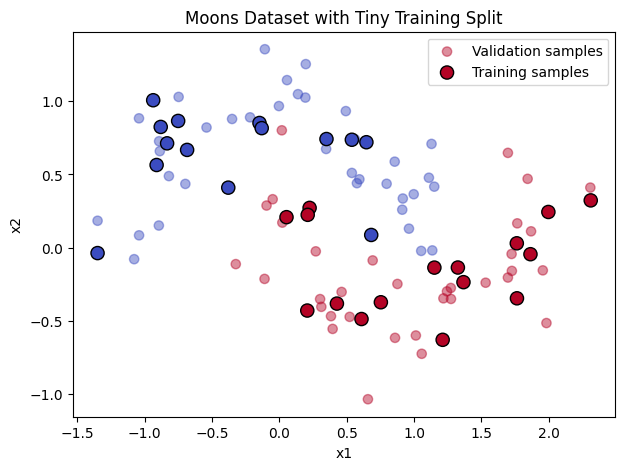

In [ ]:
# Optional check: visualize the dataset after Task 1 is complete
if all(value is not None for value in (trainX, valX, trainy, valy)):
    plt.figure(figsize=(7, 5))
    plt.scatter(valX[:, 0], valX[:, 1], c=valy.squeeze(), cmap='coolwarm', s=45, alpha=0.45, label='Validation samples')
    plt.scatter(trainX[:, 0], trainX[:, 1], c=trainy.squeeze(), cmap='coolwarm', s=90, edgecolor='black', label='Training samples')
    plt.title('Moons Dataset with Tiny Training Split')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.show()
else:
    print('TODO: finish Task 1 before plotting the dataset.')

## Task 1: Create the Dataset

Checkpoint before moving on:
- `trainX.shape[0] == 30`
- `valX.shape[0] == 70`
- both dataloaders run without errors

In [ ]:
# TODO 1.1: wrap each train/validation split in a TensorDataset
train_dataset = TensorDataset(trainX, trainy)
val_dataset = TensorDataset(valX, valy)

# TODO 1.2: build DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# print some sanity checks for the DataLoaders
print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Example batch shapes:', next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape)

Train batches: 2
Validation batches: 5
Example batch shapes: torch.Size([16, 2]) torch.Size([16, 1])


In [ ]:
# Quick class-balance check for each split
train_class_counts = torch.bincount(trainy.squeeze().long())
val_class_counts = torch.bincount(valy.squeeze().long())

print('Train class counts:', train_class_counts.tolist())
print('Validation class counts:', val_class_counts.tolist())

Train class counts: [14, 16]
Validation class counts: [36, 34]


## Task 2: Create the MLP

Use the same modeling idea as the case study: a network that is larger than necessary so it has room to overfit.

Complete the following TODOs:
1. Build a PyTorch module named `MoonsMLP`.
2. Set `input_dim=2` because each moon sample has two features.
3. Use one hidden layer with `hidden_dim=500` and `ReLU` activation.
4. Add optional dropout through a `dropout_p` argument.
5. Use one output neuron for binary classification.
6. Do **not** apply `sigmoid` inside the model because training will use `BCEWithLogitsLoss`.

Checkpoint before moving on:
- the model instantiates without errors
- a forward pass on a batch returns shape `[batch_size, 1]`

In [ ]:
class MoonsMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=500, dropout_p=0.0):
        super().__init__()
        # TODO 2.1: define the hidden layer, activation, dropout, and output layer
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout_p)
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # TODO 2.2: implement the forward pass in the correct order
        x = self.hidden(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.output(x)
        return x


# TODO 2.3: instantiate the MoonsMLP and print its architecture
baseline_model = MoonsMLP(hidden_dim=500, dropout_p=0.0)

print(baseline_model)


MoonsMLP(
  (hidden): Linear(in_features=2, out_features=500, bias=True)
  (activation): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
  (output): Linear(in_features=500, out_features=1, bias=True)
)


## Task 3: Train and Observe

In this task, you will train two models:
1. A baseline model with no dropout and no weight decay.
2. A regularized model where you experiment with dropout and weight decay.

Complete the following TODOs:
1. Write an evaluation function for loss and accuracy.
2. Write a training loop that stores train and validation history.
3. Train the baseline model.
4. Train one regularized model.
5. Compare the two histories in the plot cell below.



In [ ]:
def binary_accuracy_from_logits(logits, targets):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    accuracy = (preds == targets).float().mean()
    return accuracy.item()


def evaluate_model(model, data_loader, criterion):
    # TODO 3.1: evaluate the model over one dataloader and return loss and accuracy
    model.eval() # set model to evaluation mode to disable dropout and other training-specific behavior
    total_loss = 0.0
    total_acc = 0.0
    total_samples = 0

    with torch.no_grad():
        for xb, yb in data_loader:
            logits = model(xb)
            loss = criterion(logits,yb)
            acc = binary_accuracy_from_logits(logits,yb)

            total_loss = total_loss + loss.item() * len(yb )# accumulate total loss, note that the loss you get from the criterion is averaged over the batch, so you should multiply by the batch size to get total loss for the batch
            total_acc = total_acc + acc * len(yb)  # accumulate total accuracy, note that the accuracy you get from binary_accuracy_from_logits is averaged over the batch, so you should multiply by the batch size to get total correct predictions for the batch
            total_samples = total_samples + len(yb)  # accumulate total samples

    return total_loss / total_samples, total_acc / total_samples


def train_model(model, train_loader, val_loader, optimizer, epochs=4000, log_every=500):
    # TODO 3.2: train the model and store train/validation loss and accuracy history
    criterion = nn.BCEWithLogitsLoss()  # choose an appropriate loss function for binary classification, and remember that your model outputs logits, so you should use the version of the loss function that expects logits. (BCEWithLogitsLoss or BCELoss?)
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
    }

    for epoch in range(1, epochs + 1):
        model.train() # set model to train mode
        for xb, yb in train_loader: # loop over batches in the training set
            optimizer.zero_grad() # zero the gradients before each backward pass
            logits = model(xb) # forward pass to get logits
            loss = criterion(logits, yb) # compute the loss
            loss.backward() # backward pass to compute gradients
            optimizer.step() # update the parameters using the optimizer

        train_loss, train_acc = evaluate_model(model, train_loader, criterion) # evaluate the model on the training set using the evaluate_model function
        val_loss, val_acc = evaluate_model(model, val_loader, criterion) # evaluate the model on the validation set using the evaluate_model function

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if epoch % log_every == 0 or epoch == 1 or epoch == epochs:
            print(
                f"Epoch {epoch:4d} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}"
            )
    return history


history_baseline = None
history_regularized = None

# train the baseline model, settings: dropout_p=0.0, weight_decay=0.0
print("Training regularized model with no regularization...")
baseline_model = MoonsMLP(hidden_dim=500, dropout_p=0.0)
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001, weight_decay=0.0)
history_baseline = train_model(baseline_model, train_loader, val_loader, baseline_optimizer, epochs=4000, log_every=500)

# train one regularized model, settings: dropout_p=0.4, weight_decay=1e-4
print("Training regularized model with weight decay + dropout...")
regularized_model = MoonsMLP(hidden_dim=500, dropout_p=0.4)
regularized_optimizer = torch.optim.Adam(regularized_model.parameters(), lr=0.001, weight_decay=1e-4)
history_regularized = train_model(regularized_model, train_loader, val_loader, regularized_optimizer, epochs=4000, log_every=500)

Training regularized model with no regularization...
Epoch    1 | Train Loss: 0.6436 | Val Loss: 0.6606 | Train Acc: 0.833 | Val Acc: 0.743
Epoch  500 | Train Loss: 0.0123 | Val Loss: 0.2310 | Train Acc: 1.000 | Val Acc: 0.943
Epoch 1000 | Train Loss: 0.0020 | Val Loss: 0.2918 | Train Acc: 1.000 | Val Acc: 0.943
Epoch 1500 | Train Loss: 0.0007 | Val Loss: 0.3436 | Train Acc: 1.000 | Val Acc: 0.929
Epoch 2000 | Train Loss: 0.0003 | Val Loss: 0.3876 | Train Acc: 1.000 | Val Acc: 0.929
Epoch 2500 | Train Loss: 0.0001 | Val Loss: 0.4279 | Train Acc: 1.000 | Val Acc: 0.914
Epoch 3000 | Train Loss: 0.0001 | Val Loss: 0.4660 | Train Acc: 1.000 | Val Acc: 0.914
Epoch 3500 | Train Loss: 0.0000 | Val Loss: 0.5017 | Train Acc: 1.000 | Val Acc: 0.914
Epoch 4000 | Train Loss: 0.0000 | Val Loss: 0.5376 | Train Acc: 1.000 | Val Acc: 0.914
Training regularized model with weight decay + dropout...
Epoch    1 | Train Loss: 0.6465 | Val Loss: 0.6516 | Train Acc: 0.600 | Val Acc: 0.686
Epoch  500 | Train 

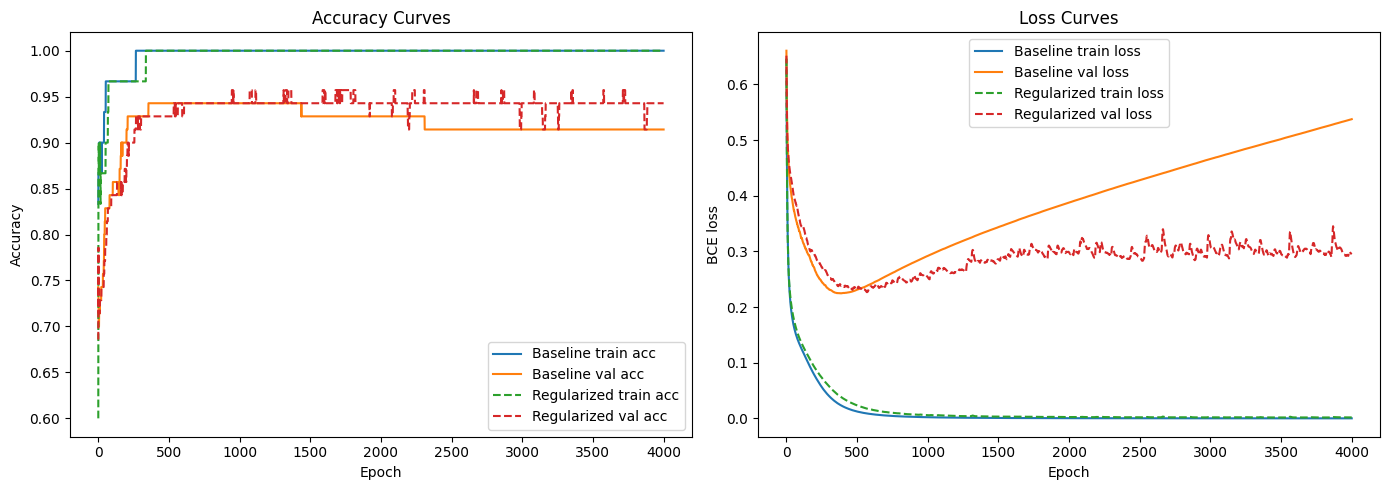

Epoch    1 | Train Loss: 0.5924 | Val Loss: 0.6266 | Train Acc: 0.867 | Val Acc: 0.729
Epoch 4000 | Train Loss: 0.0000 | Val Loss: 0.5415 | Train Acc: 1.000 | Val Acc: 0.914
dropout_p=0.0 | weight_decay=0.0   | Final Val Loss: 0.5415 | Final Val Acc: 0.914
Epoch    1 | Train Loss: 0.5925 | Val Loss: 0.6266 | Train Acc: 0.867 | Val Acc: 0.729
Epoch 4000 | Train Loss: 0.0018 | Val Loss: 0.3172 | Train Acc: 1.000 | Val Acc: 0.929
dropout_p=0.0 | weight_decay=1e-4  | Final Val Loss: 0.3172 | Final Val Acc: 0.929

Epoch    1 | Train Loss: 0.5939 | Val Loss: 0.6274 | Train Acc: 0.867 | Val Acc: 0.729
Epoch 4000 | Train Loss: 0.0000 | Val Loss: 0.4967 | Train Acc: 1.000 | Val Acc: 0.929
dropout_p=0.2 | weight_decay=0.0   | Final Val Loss: 0.4967 | Final Val Acc: 0.929
Epoch    1 | Train Loss: 0.5938 | Val Loss: 0.6274 | Train Acc: 0.867 | Val Acc: 0.729
Epoch 4000 | Train Loss: 0.0016 | Val Loss: 0.2972 | Train Acc: 1.000 | Val Acc: 0.943
dropout_p=0.2 | weight_decay=1e-4  | Final Val Loss: 0

In [ ]:
def plot_histories(history_baseline, history_regularized):
    epochs = np.arange(1, len(history_baseline['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history_baseline['train_acc'], label='Baseline train acc')
    axes[0].plot(epochs, history_baseline['val_acc'], label='Baseline val acc')
    axes[0].plot(epochs, history_regularized['train_acc'], label='Regularized train acc', linestyle='--')
    axes[0].plot(epochs, history_regularized['val_acc'], label='Regularized val acc', linestyle='--')
    axes[0].set_title('Accuracy Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(epochs, history_baseline['train_loss'], label='Baseline train loss')
    axes[1].plot(epochs, history_baseline['val_loss'], label='Baseline val loss')
    axes[1].plot(epochs, history_regularized['train_loss'], label='Regularized train loss', linestyle='--')
    axes[1].plot(epochs, history_regularized['val_loss'], label='Regularized val loss', linestyle='--')
    axes[1].set_title('Loss Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('BCE loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()



plot_histories(history_baseline, history_regularized)

# Reflection question 3 and 4:

for dropout_p in [0.0, 0.2, 0.4, 0.6]:
        torch.manual_seed(42)
        model_no_wd = MoonsMLP(hidden_dim=500, dropout_p=dropout_p)
        optimizer_no_wd = torch.optim.Adam(model_no_wd.parameters(), lr=0.001, weight_decay=0.0)
        history_no_wd = train_model(model_no_wd, train_loader, val_loader, optimizer_no_wd, epochs=4000, log_every=4000)
        print(f"dropout_p={dropout_p} | weight_decay=0.0   | Final Val Loss: {history_no_wd['val_loss'][-1]:.4f} | Final Val Acc: {history_no_wd['val_acc'][-1]:.3f}")

        torch.manual_seed(42)
        model_with_wd = MoonsMLP(hidden_dim=500, dropout_p=dropout_p)
        optimizer_with_wd = torch.optim.Adam(model_with_wd.parameters(), lr=0.001, weight_decay=1e-4)
        history_with_wd = train_model(model_with_wd, train_loader, val_loader, optimizer_with_wd, epochs=4000, log_every=4000)
        print(f"dropout_p={dropout_p} | weight_decay=1e-4  | Final Val Loss: {history_with_wd['val_loss'][-1]:.4f} | Final Val Acc: {history_with_wd['val_acc'][-1]:.3f}")
        print()


## Reflection

Be specific and refer to your own curves and results.

1. What evidence shows that the baseline model overfits?
2. At approximately which epoch does validation performance look best?
3. Try `dropout_p` in `[0.0, 0.2, 0.4, 0.6]`,  compare the validation loss and validation accuracy for different dropout rates. Which `dropout_p` value gives the best performance?
4. For each value of `dropout_p`, try `weight_decay=1e-4`, and compare the performance with models that do not use weight decay.
5. Which regularization method appears to improve generalization more: dropout or weight decay? How do you observe this, and what is a possible reason?
6. What additional experiments could you perform to further improve generalization?

## Your Answers:
1. In lecture 3, overfitting is referred to as when a model learns noise and details in training. Lecture 3 also states that a key sign of overfitting is good performance on the training data and poor generlisation to other data, which is evident in my results. In epoch 1 the train loss is 0.6760 and decreases significantly to 0.0000 by epoch 4000, where as the validation loss at epoch 500 is 0.2392 and increases to 0.5670 by epoch 4000. This shows that the model performs well on training data and not well on unseen data. Furthermore the model shows perfect training data as at epoch 500 the training accuracy is 1.000, whilst the validation accuracy is 0.943 at epoch 500 and declines to 0.914 by epoch 4000.

2. The results suggest that epoch 500 is where validation performance is at its best. This is because the validation loss is 0.2392, which is the lowest loss value, and the validation accuracy is 0.943, which is the highest accuracy score. The results show, after epoch 500 the val accuracy decreases and the val loss increases.

3. The results show without weight decay dropout_p=0.4 was the best performing validation accuracy at 0.943, dropout_p=0.2 and dropout_p=0.6 both tie at 0.929 and the baseline (dropout_p=0.0) has the worst val accuracy of 0.914. Initially dropout_p=0.2 was the best performing validating loss (0.467) without weight decay however it is also the best performing validation loss (0.2972) after the weight decay is applied. Also continues to performing well in validation accuracy (0.929 to 0.943) after weight decay is applied, which ties with dropout_p=0.4 and dropout_p=0.6. To conclude 0.2 is the overall best performing droupout_p.

4.  The results suggest that the models perform better with the application weight decay and there is a consistent improvement in validation loss. dropout_p=0.0 went from 0.5415 to 0.3172, dropout_p=0.2 dropped from 0.4967 to 0.2972, dropout_p=0.4 went from 0.5132 to 0.3160 and lastly dropout_p=0.6 went from 0.5475 to 0.3499. Also there was a slight increase in validation accuracy when weight decay was applied as dropout_p=0.0 increased from 0.914 to 0.929, dropout_p=0.2 went from 0.929 to 0.943 and dropout_p=0.6 increased from 0.929 to 0.943. dropout_p=0.4 was the only validation accuracy that was not affected and stayed the same (0.943).

5. In this exercise, weight decay is the regularization technique that improves generalization more. In validation loss, changing the dropout value we can see inconsistencies for example in dropout_p=0.0 the validation loss is 0.5415, then decreases to 0.4967 however increase to 0.5132 in dropout_0.4 and again in dropout_p=0.6 (0.5457). However when the regularisation technique weight decay is applied the results shows a consistently larger decrease in validation loss. This is evident here dropout_p=0.0 is 0.3172, dropout_p=0.2 is 0.2972 and dropout_p=0.4 is 0.3160. Lecture states that L1/L2 Regularization encourages weights to remain small by adding a penalty proportional the squared magnitude of the weights where as Dropout aims for the network to learn more robust represenations by disabling a portions of neurons in every training step.

6. There are several ways generalisation can be improved and overfitting can be addressed. One experiment is early stopping, this monitors the validation set during training and stops when validation errors stop improving. In this case the model would stop at epoch 500, rather than continuing to epoch 4000 where the model overfitting occurs. Another solution is by adding more training data, in this case we only have 30 samples for the model to train from. Applying data augmentation improves performance and reduces overfitting. This solution artificially increases the diversity and size of the training set. For example in audio this can be done by time shifts and adding noise.